<a href="https://colab.research.google.com/github/FRA-0023/Causal-Networks/blob/main/notebooks/causal_inference_with_dowhy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Table of Contents

*   [Causal Inference with DoWhy](#causal-inference-with-dowhy)
*   [Step 1: Generate a Dataset](#step-1-generate-a-dataset)
*   [Step 2: Construct a Model](#step-2-construct-a-model)
*   [Identify the Estimand](#identify-the-estimand)
*   [Estimate the Average Causal Effect](#estimate-the-average-causal-effect)
*   [Evaluate the Results](#evaluate-the-results)

In [1]:
%%capture
# Install the 'dowhy' library, a powerful tool for causal inference.
# We are installing the latest version to ensure compatibility and access to recent features and bug fixes.
# The '%%capture' command suppresses the output of this cell, keeping our notebook clean.
!pip install dowhy

In [2]:
import warnings
# Filter out any warnings that might be generated by the libraries.
# This helps keep our output focused on the results rather than potential alerts.
warnings.filterwarnings("ignore")

In [3]:
# Import necessary libraries for causal inference and data manipulation.
import dowhy         # The main library for performing causal inference.
import dowhy.api     # Provides a high-level API for DoWhy.
import dowhy.datasets # Used to generate synthetic datasets for examples.
import dowhy.plotter # For visualizing causal graphs (though not directly used for plotting in this notebook).
import numpy as np   # Fundamental package for numerical operations, especially useful for random number generation.

# Causal Inference with DoWhy

This notebook represents a quick-start guide to causal inference using the [DoWhy](https://github.com/microsoft/dowhy) package.

## Step 1: Generate a Dataset

Set the random seed generator for result reproducibility.

In [4]:
# Set a random seed for NumPy. This ensures that any random operations (like dataset generation)
# will produce the exact same results every time the code is run. This is crucial for reproducibility.
np.random.seed(33)

DoWhy allows the generation of a dataset by specifying a set of parameters.

In [5]:
# Generate a synthetic dataset using DoWhy's built-in utility.
# This function creates a dataset with a predefined causal structure, which is excellent for testing.
dataset = dowhy.datasets.linear_dataset(
    beta = 3,                       # Defines the strength of the causal effect (coefficient for the treatment variable).
    num_samples = int(1e4),         # Generates 10,000 data points (rows) for our dataset.
    num_common_causes = 2,          # Specifies that there are 2 confounding variables (common causes).
    num_frontdoor_variables = 1,    # Specifies that there is 1 frontdoor variable (mediator).
    treatment_is_binary = True,     # The treatment variable will be binary (e.g., True/False, 0/1).
    outcome_is_binary = True        # The outcome variable will also be binary.
)

# Display the keys of the generated dataset dictionary.
# This shows us what information is contained within the 'dataset' object.
list(dataset.keys())

['df',
 'treatment_name',
 'outcome_name',
 'common_causes_names',
 'instrument_names',
 'effect_modifier_names',
 'frontdoor_variables_names',
 'dot_graph',
 'gml_graph',
 'ate']

It will return a dictionary with a Pandas DataFrame, along with a set of variables names and the true causal graph used for the sampling process.

In [6]:
# Unpack the values from the 'dataset' dictionary into individual variables.
# This makes it easier to access specific components like the DataFrame, treatment name, etc.
data, [treatment], outcome, _, _, _, _, _, causal_graph, ace = dataset.values()

# data: A Pandas DataFrame containing the generated observational data.
# [treatment]: A list containing the name of the treatment variable.
# outcome: The name of the outcome variable.
# _: Underscores are used as placeholders for values we don't need to explicitly store (e.g., instrument_names).
# causal_graph: The true causal graph in a format compatible with DoWhy (e.g., GML or DOT).
# ace: The true Average Causal Effect (ATE) for this synthetic dataset, which we will compare our estimates against.

After unpacking the values of the dictionary, it is possible to observe the assigned names to the data columns:

**Note**: To ensure compatibility with causal inference estimators, we will explicitly convert the boolean treatment and outcome columns to integers (0s and 1s) **before** constructing the `CausalModel`.

In [7]:
# Print the names of the treatment and outcome variables.
# This helps us confirm what DoWhy has named these key variables in our dataset.
treatment, outcome

('v0', 'y')

It also return the true average causal effect:

In [8]:
# Print the true Average Causal Effect (ACE) from the generated dataset.
# In a real-world scenario, this value would be unknown, but for synthetic data, it serves as a ground truth for evaluation.
ace

np.float64(0.1219)

In [9]:
# Display the first few rows and summary of the generated DataFrame.
# This gives us a quick look at the structure and content of our observational data.
data

,FD0,W0,W1,v0,y
0,-0.808793,-2.038198,-0.670450,False,False
1,-0.847388,-0.719708,0.154825,False,False
2,1.871803,-0.652430,1.910733,True,True
3,-0.163010,-0.599764,0.322153,True,True
4,-2.410111,-0.728441,-0.737992,False,False
...,...,...,...,...,...
9995,2.095709,0.225739,1.332569,True,True
9996,1.251388,-1.529271,0.724498,True,True
9997,0.760808,-0.191442,-0.352940,True,True
9998,1.101175,-0.126650,1.465335,True,True


## Step 2: Construct a Model

The second step consists in constructing a causal model using the true graph.

In [10]:
# Create a copy of the data and ensure treatment and outcome are integers for compatibility with all estimators.
# This addresses a TypeError related to numpy boolean subtraction that can occur with some estimators.
processed_data = data.copy()

# Using .apply(int) for explicit casting of each boolean value to an integer (0 or 1).
# This ensures compatibility with estimators that might perform arithmetic operations.
processed_data[treatment] = processed_data[treatment].apply(int)
processed_data[outcome] = processed_data[outcome].apply(int)

# Construct a CausalModel object using DoWhy.
# This object encapsulates the data, the defined treatment and outcome, till the causal graph.
# It's the central object in DoWhy for performing causal inference steps.
model = dowhy.CausalModel(
    data = processed_data, # Use the processed data with integer types for treatment and outcome.
    treatment = treatment, # The name of the treatment variable.
    outcome = outcome,     # The name of the outcome variable.
    graph = causal_graph   # The causal graph representing known causal relationships.
)

It is not a proper SCM as we seen in previous sessions. It is more like a container for the data and the graph.

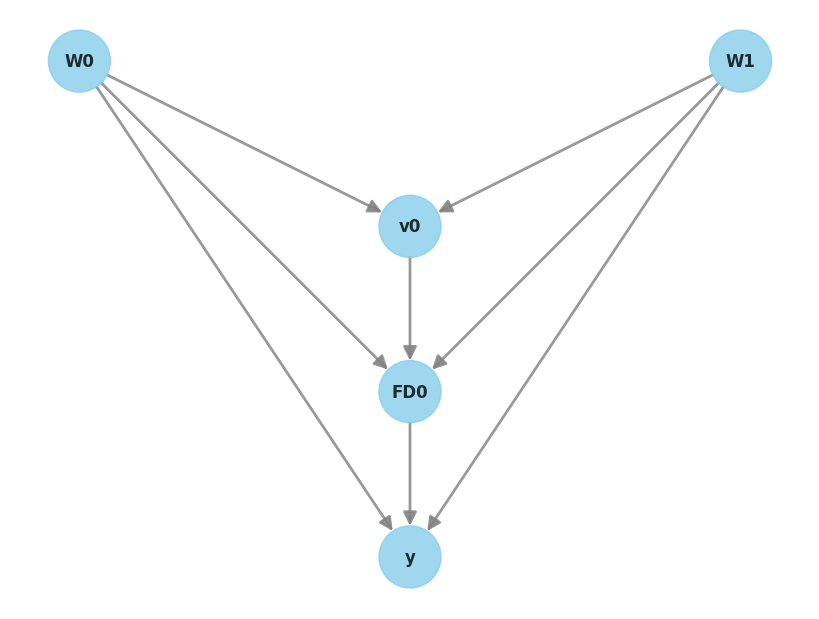

In [11]:
# Visualize the causal model's graph. DoWhy internally generates a DOT representation.
# 'layout="dot"' specifies the layout engine for rendering the graph.
# This visualization helps us understand the assumed causal structure, including confounders (W0, W1) and mediators (FD0).
model.view_model(layout="dot")

# The following commented lines are for displaying the generated image in environments where
# 'view_model' might save to a file and require explicit display (like local Jupyter notebooks).
# from IPython.display import Image, display
# display(Image(filename="causal_model.png"))

This will enable the identification step by using a couple of handful methods.

## Step 3: Identify the Estimand

The estimand identification tests for both backdoor and frontdoor criterion.

In [12]:
# Identify the estimand from the causal model.
# An estimand is a statistical expression that can be estimated from data and represents the causal effect of interest.
# DoWhy tries to find an identifiable estimand using methods like the backdoor criterion or frontdoor criterion.

# 'proceed_when_unidentifiable=True' allows the process to continue even if a perfect identification is not possible,
# which is useful for exploring potential estimands.
estimand = model.identify_effect(proceed_when_unidentifiable=True)

# Print the identified estimand(s).
# This output details the mathematical expression for the causal effect and any assumptions made.
print(estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
  d              
─────(E[y|W1,W0])
d[v₀]            
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W1,W0,U) = P(y|v0,W1,W0)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
  d              
─────(E[y|W1,W0])
d[v₀]            
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W1,W0,U) = P(y|v0,W1,W0)



## Step 4: Estimate the Average Causal Effect

Once the estimand has been identified, we can proceed to the last estimation step.

In [13]:
# Define a list of different estimation methods (estimators) to be used.
# These methods are designed to estimate the causal effect (ATE) based on the identified estimand.

estimators = [
    # 'backdoor.linear_regression': This method estimates the causal effect by fitting a linear regression model.
    # It includes the treatment variable and identified confounders (common causes) as predictors
    # to control for their influence on the outcome.
    "backdoor.linear_regression",

    # 'backdoor.propensity_score_stratification': This technique involves estimating propensity scores
    # (the probability of receiving treatment given observed confounders) for each unit. The data is then
    # divided into strata based on similar propensity scores. Within each stratum, treated and control
    # units are more comparable, and the causal effect is estimated by averaging effects across strata.
    "backdoor.propensity_score_stratification",

    # 'backdoor.propensity_score_weighting': This method uses inverse propensity score weighting (IPW).
    # Each unit is weighted by the inverse of its propensity score (or one minus the propensity score for controls).
    # This re-weights the observational data to create a 'pseudo-population' where the treatment assignment
    # is unconfounded, allowing for a more unbiased estimate of the causal effect.
    "backdoor.propensity_score_weighting",

    # 'backdoor.propensity_score_matching': This method also uses propensity scores. For each treated unit,
    # it finds one or more control units with similar propensity scores. By matching units, it creates
    # comparable groups that differ primarily in their treatment status, thereby helping to isolate the causal effect.
    "backdoor.propensity_score_matching",
]

We will iterate over the provided methods and compare the results.

In [14]:
# Iterate through each specified estimator and calculate the causal effect.
# The results are stored in a dictionary where keys are estimator names and values are the estimated effect objects.
estimates = {
    estimator: model.estimate_effect(estimand, method_name=estimator)
    for estimator in estimators
}

In [15]:
# Print the first estimated effect object to see its full structure.
# This shows details like the identified estimand, realized estimand (how it's calculated),
# and the mean value of the estimated effect.
for estimate in estimates.values():
    print(estimate)
    break # We only print the first one for brevity, as they all share a similar structure.

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
  d              
─────(E[y|W1,W0])
d[v₀]            
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W1,W0,U) = P(y|v0,W1,W0)

## Realized estimand
b: y~v0+W1+W0
Target units: ate

## Estimate
Mean value: 0.13535578974430718



In [16]:
# Iterate through all the calculated estimates and print a summary for each.
# For each estimator, it displays:
# - The name of the estimator used.
# - The estimated causal effect value, formatted to four decimal places.
# - The relative error compared to the true Average Causal Effect (ACE), formatted as a percentage.
#   The formula for relative error is: |(estimated_value - true_value) / true_value * 100|
for estimator, estimate in estimates.items():
    print(f"""
    Estimator: {estimator},
    Estimate: {estimate.value:.4},
    Relative Error: {(abs((estimate.value-ace)/ace*100)):.4}%
    """.lstrip("\n"))

    Estimator: backdoor.linear_regression,
    Estimate: 0.1354,
    Relative Error: 11.04%
    
    Estimator: backdoor.propensity_score_stratification,
    Estimate: 0.1252,
    Relative Error: 2.739%
    
    Estimator: backdoor.propensity_score_weighting,
    Estimate: 0.1665,
    Relative Error: 36.62%
    
    Estimator: backdoor.propensity_score_matching,
    Estimate: 0.2322,
    Relative Error: 90.48%
    


## Final Step: Evaluate the Results

With the estimates obtained we can setup a round of hypothesis testing. Note that, since we usually don't know the true ACE, refutation is more about the estimation procedure and not the estimate itself.

If the test's p-value is $p<0.05$, we refute the estimation; otherwise, we *don't refute* it, that is we cannot conclude anything about the correctness of the procedure. For more information, see the [DoWhy refuters page](https://www.pywhy.org/dowhy/v0.8/user_guide/effect_inference/refute.html).

In [17]:
# Define a list of refutation methods.
# Refuters are used to test the robustness of the causal estimate by introducing perturbations to the data or model.
# If an estimate is sensitive to these perturbations, it suggests the estimate might not be robust.
# 'bootstrap_refuter': Resamples the data with replacement to see if the estimate changes significantly.
# 'data_subset_refuter': Uses a random subset of the data to see if the estimate remains consistent.
# 'dummy_outcome_refuter': Replaces the actual outcome with a randomly generated one to test for spurious correlations.
# 'placebo_treatment_refuter': Replaces the actual treatment with a randomly generated one (placebo) to check if a non-existent effect is found.
# 'random_common_cause': Adds a randomly generated common cause to check if the estimate is robust to unobserved confounders.
refuters = [
    "bootstrap_refuter",
    "data_subset_refuter",
    "dummy_outcome_refuter",
    "placebo_treatment_refuter",
    "random_common_cause",
]

We will take the backdoor with linear regression as estimate of reference.

In [18]:
# Apply each refutation method to a specific estimate (here, 'backdoor.linear_regression').
# This tests the robustness of that particular estimate.
# The results are stored in a dictionary, similar to the estimates.
refuteds = {
    refuter: model.refute_estimate(
      estimand,                                   # The identified estimand.
      estimates["backdoor.linear_regression"], # The specific estimate to be refuted.
      method_name=refuter                         # The refutation method to apply.
    )
    for refuter in refuters
}

Some refuters may return a list of tests.

In [19]:
# Print the results of each refutation test.
# Each refuter returns an object detailing the original effect, the new effect after refutation,
# and a p-value. A high p-value (e.g., > 0.05) suggests that the estimate is robust to that specific refutation.
# Some refuters might return a list of tests, so we handle that case by printing the first item if it's a list.
for refuter in refuteds.values():
    print(refuter if type(refuter) != list else refuter[0])

Refute: Bootstrap Sample Dataset
Estimated effect:0.13535578974430718
New effect:0.13991033893828173
p value:0.6799999999999999

Refute: Use a subset of data
Estimated effect:0.13535578974430718
New effect:0.13567482620114313
p value:0.98

Refute: Use a Dummy Outcome
Estimated effect:0
New effect:0.0017584941005710036
p value:0.8999999999999999

Refute: Use a Placebo Treatment
Estimated effect:0.13535578974430718
New effect:0.0006949328551648787
p value:0.8799999999999999

Refute: Add a random common cause
Estimated effect:0.13535578974430718
New effect:0.13537262452054458
p value:0.8999999999999999



We may also want to test if our estimate is significantly different from 0.

In [20]:
# Re-estimate the causal effect using 'backdoor.linear_regression' but this time,
# also perform a significance test to see if the estimated effect is statistically different from zero.
# 'test_significance=True' triggers this additional statistical test.
# The output will include a p-value for the estimate, indicating the probability of observing such an effect
# if the true effect were actually zero. A low p-value (typically < 0.05) suggests statistical significance.
print(model.estimate_effect(estimand, method_name = "backdoor.linear_regression", test_significance = True))

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
  d              
─────(E[y|W1,W0])
d[v₀]            
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W1,W0,U) = P(y|v0,W1,W0)

## Realized estimand
b: y~v0+W1+W0
Target units: ate

## Estimate
Mean value: 0.13535578974430718
p-value: [1.08720934e-38]

